# Projet Data Science — Prostate cancer dataset

- Vérification des données,
- Statistiques descriptives,
- Transformation logarithmique,
- ACP,
- Régression linéaire simple,
- Best subset selection,

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import statsmodels.api as sm
import statsmodels.formula.api as smf

# -----------------------------
# Plot configuration
# -----------------------------
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

DATA_PATH = "data/prostate.txt"
TARGET = "lpsa"
ORIGINAL_COLUMNS = ["vol", "wht", "age", "bh", "pc", "psa"]
LOG_COLS = ["vol", "wht", "bh", "pc", "psa"]
PREDICTORS_LOG = ["lvol", "lwht", "age", "lbh", "lpc"]

## 1. Chargement et contrôle du jeu de données

In [2]:
prostate = pd.read_csv(DATA_PATH, sep=r"\s+")

print("Aperçu :")
display(prostate.head())

print(f"Nombre d'observations : {prostate.shape[0]}")
print(f"Nombre de variables    : {prostate.shape[1]}")
print("Valeurs manquantes :")
display(prostate.isna().sum().to_frame("missing"))

missing_cols = set(ORIGINAL_COLUMNS) - set(prostate.columns)
if missing_cols:
    raise ValueError(f"Colonnes attendues manquantes : {missing_cols}")

Aperçu :


,vol,wht,age,bh,pc,psa
0,0.56,15.95,50,0.25,0.25,0.65
1,0.37,27.65,58,0.25,0.25,0.85
2,0.60,14.75,74,0.25,0.25,0.85
3,0.30,26.65,58,0.25,0.25,0.85
4,2.12,30.95,62,0.25,0.25,1.45


Nombre d'observations : 80
Nombre de variables    : 6
Valeurs manquantes :


,missing
vol,0
wht,0
age,0
bh,0
pc,0
psa,0


## 2. Statistiques descriptives et graphiques exploratoires

In [3]:
desc = prostate.describe().T

desc["variance"] = prostate.var(numeric_only=True, ddof=1)
desc["missing"] = prostate.isna().sum()

display(desc)

,count,mean,std,min,25%,50%,75%,max,variance,missing
vol,80.0,6.77150,8.000974,0.30,1.650,3.565,8.060,45.65,64.015588,0
wht,80.0,41.58125,18.351998,10.75,29.200,38.300,48.475,111.95,336.795847,0
age,80.0,63.61250,7.897274,41.00,60.000,65.000,68.000,79.00,62.366930,0
bh,80.0,2.69175,2.989996,0.25,0.250,1.300,5.075,10.24,8.940078,0
pc,80.0,2.18875,3.677695,0.25,0.250,0.450,1.875,18.25,13.525441,0
psa,80.0,25.47250,44.306436,0.65,6.125,14.400,21.350,265.85,1963.060247,0


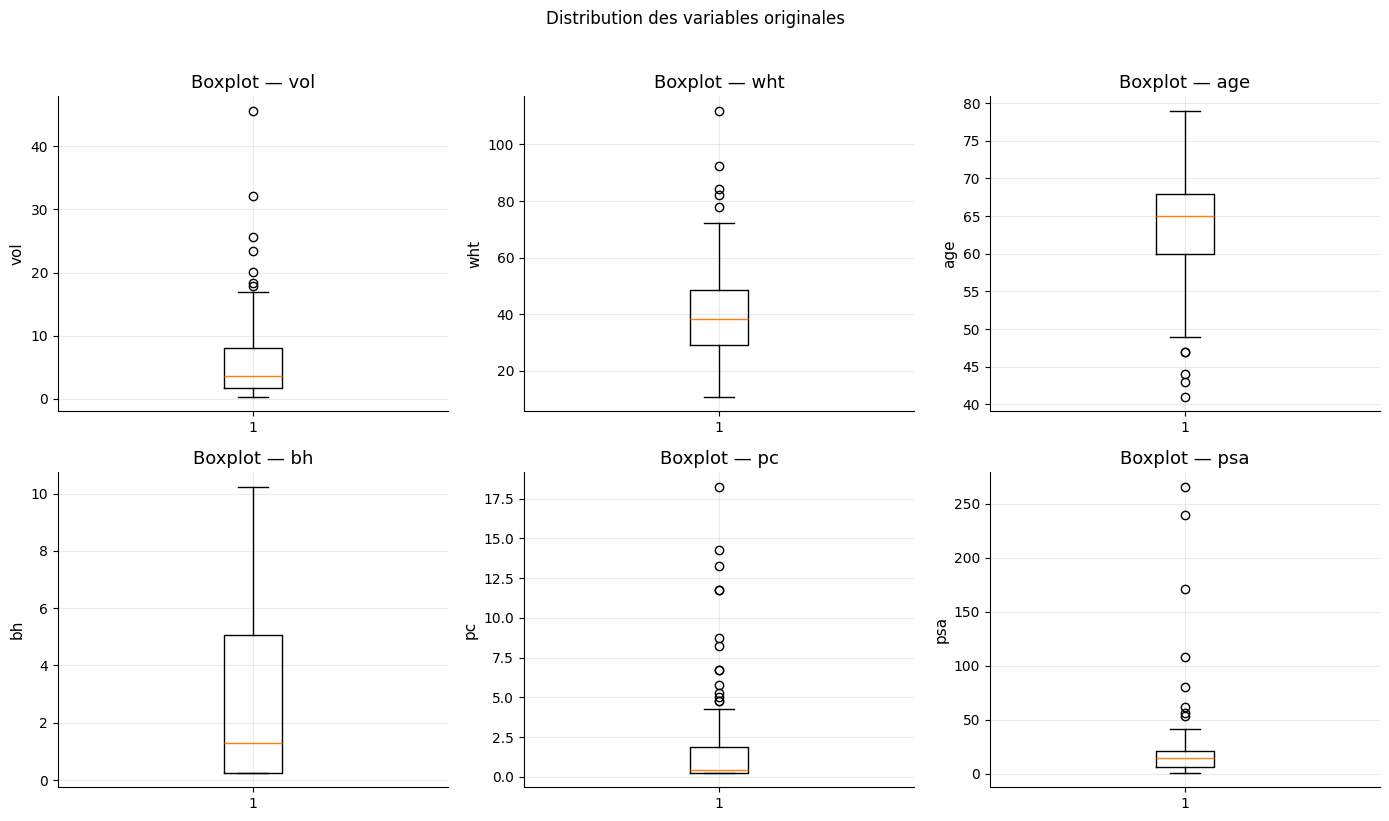

In [4]:
# Boxplots lisibles variable par variable
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, ORIGINAL_COLUMNS):
    ax.boxplot(prostate[col].dropna(), vert=True)
    ax.set_title(f"Boxplot — {col}")
    ax.set_ylabel(col)

plt.suptitle("Distribution des variables originales", y=1.02)
plt.tight_layout()
plt.show()

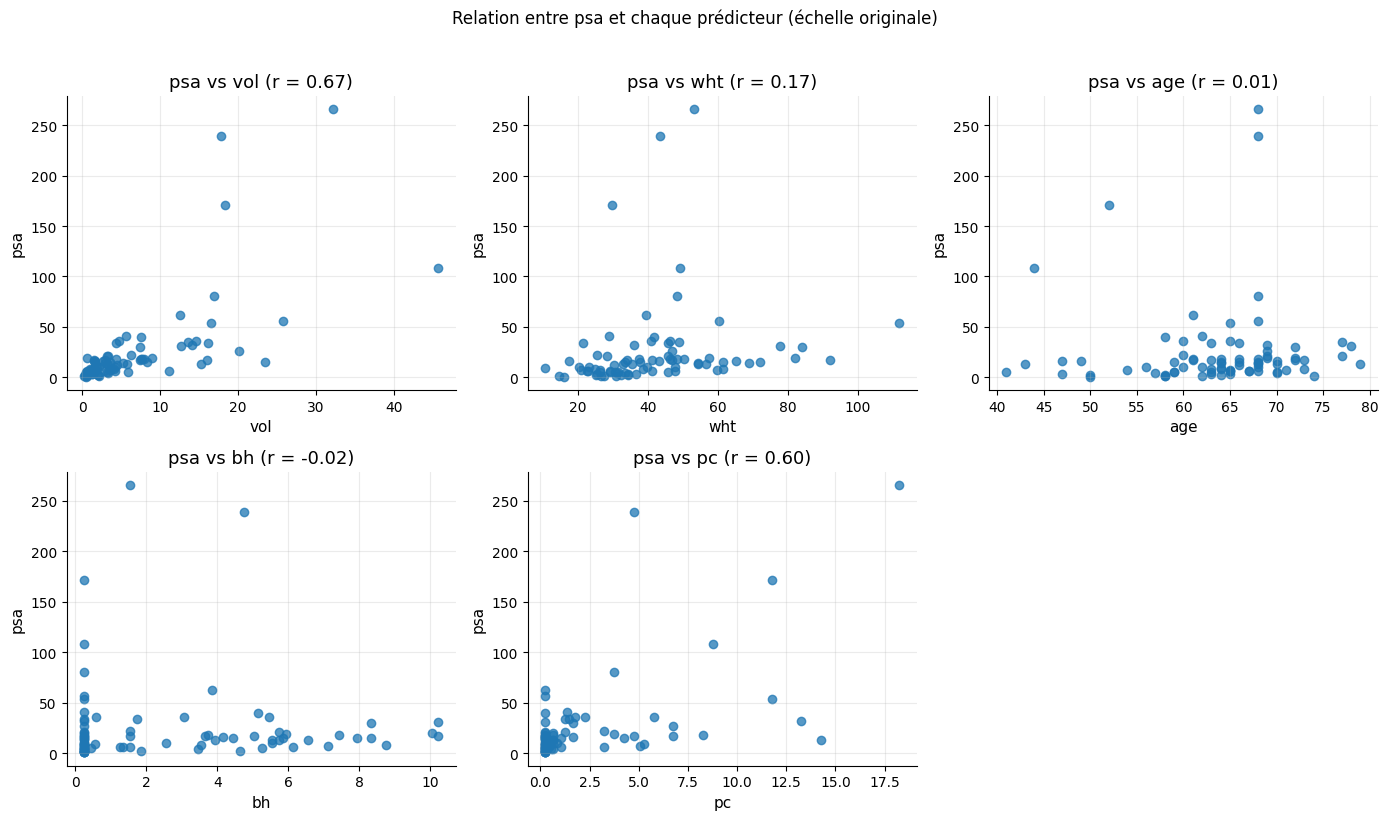

In [5]:
# Scatterplots de psa contre les autres variables
predictors_original = ["vol", "wht", "age", "bh", "pc"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, col in enumerate(predictors_original):
    x = prostate[col]
    y = prostate["psa"]
    axes[i].scatter(x, y, alpha=0.75)
    corr = prostate[[col, "psa"]].corr().iloc[0, 1]
    axes[i].set_title(f"psa vs {col} (r = {corr:.2f})")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("psa")

axes[-1].axis("off")
plt.suptitle("Relation entre psa et chaque prédicteur (échelle originale)", y=1.02)
plt.tight_layout()
plt.show()

## 3. Transformation logarithmique

L'énoncé demande de transformer logarithmiquement toutes les variables sauf `age`. On ajoute une vérification de sécurité pour éviter les erreurs si une variable à log-transformer contient une valeur non positive.

In [6]:
for col in LOG_COLS:
    if (prostate[col] <= 0).any():
        bad_n = int((prostate[col] <= 0).sum())
        raise ValueError(
            f"La colonne '{col}' contient {bad_n} valeur(s) <= 0 : log impossible sans traitement spécifique."
        )

prostate_log = prostate.copy()
for col in LOG_COLS:
    prostate_log[f"l{col}"] = np.log(prostate_log[col])

prostate_log = prostate_log[["lvol", "lwht", "age", "lbh", "lpc", "lpsa"]].copy()

print("Statistiques descriptives après transformation :")
display(prostate_log.describe().T)

print("Variances après transformation :")
display(prostate_log.var(ddof=1).to_frame("variance"))

Statistiques descriptives après transformation :


,count,mean,std,min,25%,50%,75%,max
lvol,80.0,1.288458,1.186833,-1.203973,0.500551,1.271155,2.086639,3.821004
lwht,80.0,3.637556,0.430473,2.374906,3.374164,3.645381,3.881038,4.718052
age,80.0,63.612500,7.897274,41.000000,60.000000,65.000000,68.000000,79.000000
lbh,80.0,0.096931,1.470575,-1.386294,-1.386294,0.261624,1.624290,2.326302
lpc,80.0,-0.265689,1.366742,-1.386294,-1.386294,-0.798508,0.622444,2.904165
lpsa,80.0,2.507034,1.201612,-0.430783,1.812354,2.667174,3.061019,5.582932


Variances après transformation :


,variance
lvol,1.408574
lwht,0.185307
age,62.366930
lbh,2.162591
lpc,1.867984
lpsa,1.443872


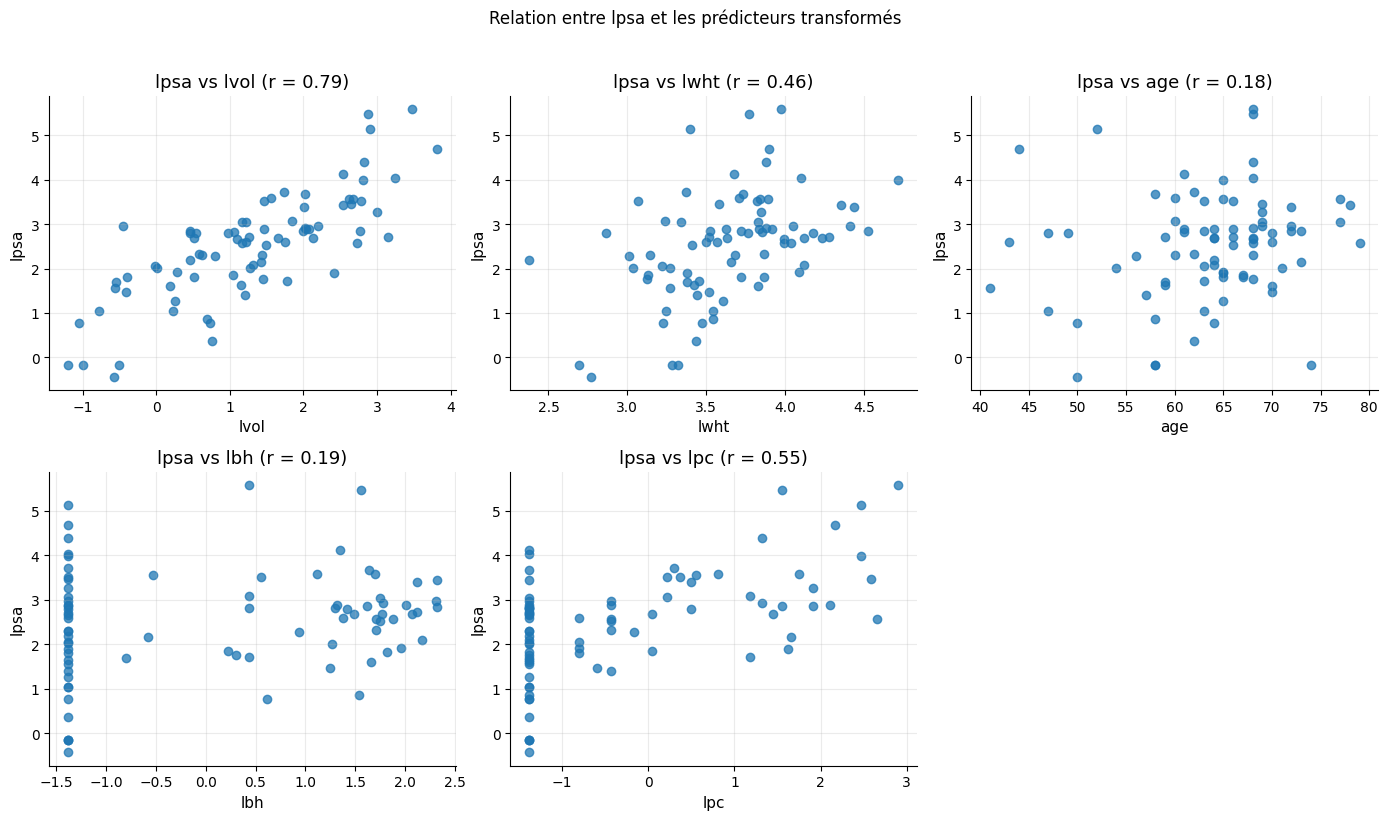

In [7]:
# Scatterplots après transformation
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for i, col in enumerate(PREDICTORS_LOG):
    x = prostate_log[col]
    y = prostate_log["lpsa"]
    axes[i].scatter(x, y, alpha=0.75)
    corr = prostate_log[[col, "lpsa"]].corr().iloc[0, 1]
    axes[i].set_title(f"lpsa vs {col} (r = {corr:.2f})")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("lpsa")

axes[-1].axis("off")
plt.suptitle("Relation entre lpsa et les prédicteurs transformés", y=1.02)
plt.tight_layout()
plt.show()

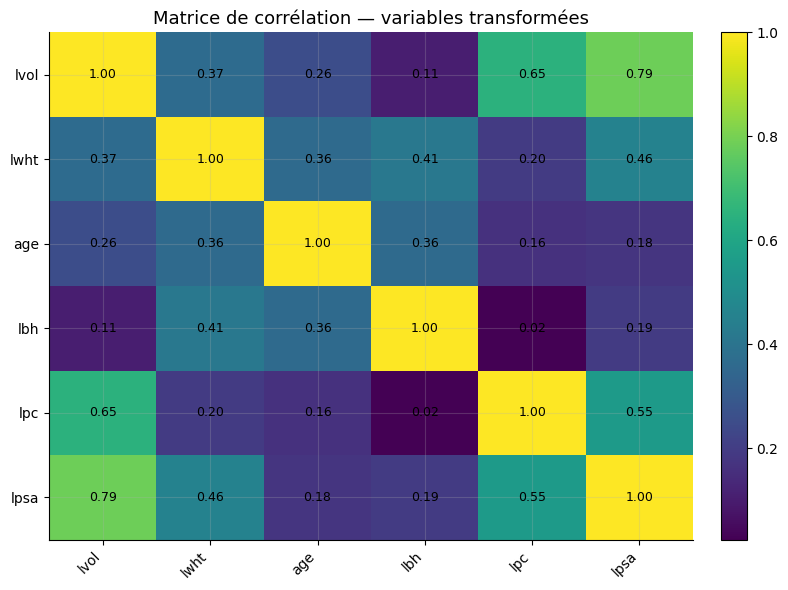

In [8]:
# Matrice de corrélation plus utile qu'un pairplot très chargé pour le rapport
corr = prostate_log.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Matrice de corrélation — variables transformées")

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 4. ACP (PCA)

Comme les variances des variables transformées restent différentes, l'ACP est réalisée **sur variables standardisées**.

In [9]:
X_pca = prostate_log[["lvol", "lwht", "age", "lbh", "lpc", "lpsa"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

pca = PCA()
X_scores = pca.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca.components_.T,
    index=X_pca.columns,
    columns=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)

pve = pca.explained_variance_ratio_
cum_pve = np.cumsum(pve)

pve_df = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(pve))],
    "PVE": pve,
    "Cumulative_PVE": cum_pve,
})

print("Loadings :")
display(loadings.round(3))

print("Variance expliquée :")
display(pve_df.round(3))

Loadings :


,PC1,PC2,PC3,PC4,PC5,PC6
lvol,0.514,-0.290,0.038,-0.009,-0.349,0.727
lwht,0.396,0.360,-0.400,-0.594,0.439,0.089
age,0.291,0.459,0.794,-0.190,-0.144,-0.136
lbh,0.242,0.612,-0.269,0.698,-0.038,0.077
lpc,0.418,-0.392,0.258,0.351,0.681,-0.134
lpsa,0.511,-0.217,-0.264,-0.041,-0.446,-0.649


Variance expliquée :


,Component,PVE,Cumulative_PVE
0,PC1,0.465,0.465
1,PC2,0.230,0.695
2,PC3,0.117,0.812
3,PC4,0.092,0.903
4,PC5,0.066,0.969
5,PC6,0.031,1.000


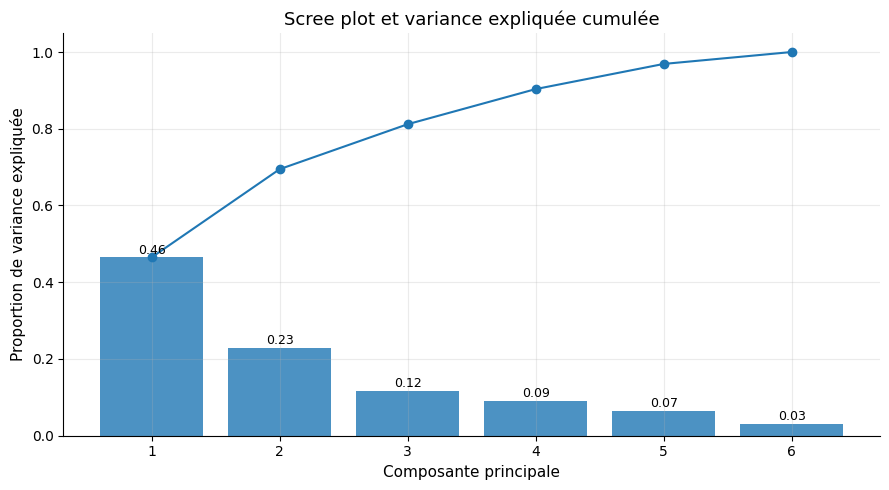

In [10]:
# Scree plot + courbe cumulée
components = np.arange(1, len(pve) + 1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(components, pve, alpha=0.8)
ax.plot(components, cum_pve, marker="o")
ax.set_xticks(components)
ax.set_xlabel("Composante principale")
ax.set_ylabel("Proportion de variance expliquée")
ax.set_title("Scree plot et variance expliquée cumulée")

for x, y in zip(components, pve):
    ax.text(x, y + 0.01, f"{y:.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

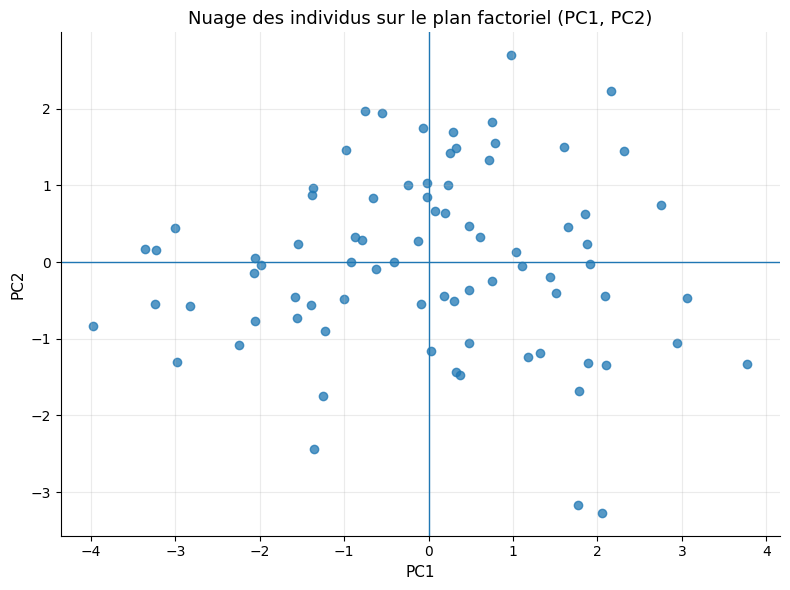

In [11]:
# Scores plot PC1 / PC2
scores_df = pd.DataFrame(X_scores[:, :2], columns=["PC1", "PC2"])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(scores_df["PC1"], scores_df["PC2"], alpha=0.75)
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_title("Nuage des individus sur le plan factoriel (PC1, PC2)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.show()

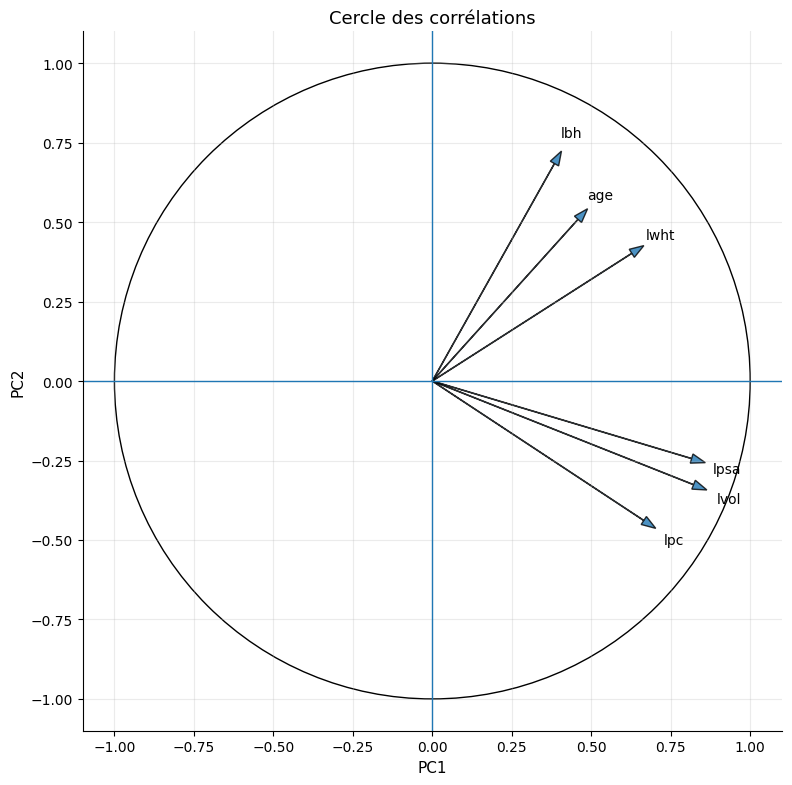

In [12]:
# Cercle des corrélations
# Corr(variable_j, PC_k) = loading_jk * sqrt(eigenvalue_k) pour ACP sur données standardisées
corr_circle = pd.DataFrame(
    pca.components_.T[:, :2] * np.sqrt(pca.explained_variance_[:2]),
    index=X_pca.columns,
    columns=["PC1", "PC2"]
)

fig, ax = plt.subplots(figsize=(8, 8))
unit_circle = plt.Circle((0, 0), 1, fill=False)
ax.add_patch(unit_circle)

for var in corr_circle.index:
    x, y = corr_circle.loc[var, ["PC1", "PC2"]]
    ax.arrow(0, 0, x, y, alpha=0.8, head_width=0.03, length_includes_head=True)
    ax.text(1.08 * x, 1.08 * y, var, ha="center", va="center")

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Cercle des corrélations")
plt.tight_layout()
plt.show()

## 5. Rappel théorique sur \(R^2\)

In [13]:
print("Interprétation : R² mesure la proportion de la variance de Y expliquée par le modèle.")
print("En régression linéaire avec constante, 0 <= R² <= 1.")
print("Avec deux prédicteurs X1 et X2 :")
print("R² = (r1² + r2² - 2*r1*r2*r12) / (1 - r12²)")
print("où r1 = corr(X1, Y), r2 = corr(X2, Y), r12 = corr(X1, X2).")
print("Si X1 et X2 sont non corrélés (r12 = 0), alors R² = r1² + r2².")

Interprétation : R² mesure la proportion de la variance de Y expliquée par le modèle.
En régression linéaire avec constante, 0 <= R² <= 1.
Avec deux prédicteurs X1 et X2 :
R² = (r1² + r2² - 2*r1*r2*r12) / (1 - r12²)
où r1 = corr(X1, Y), r2 = corr(X2, Y), r12 = corr(X1, X2).
Si X1 et X2 sont non corrélés (r12 = 0), alors R² = r1² + r2².


## 6. Régression linéaire simple

In [14]:
corr_with_target = prostate_log.corr()[TARGET].drop(TARGET).sort_values(ascending=False)
print("Corrélations avec lpsa :")
display(corr_with_target.to_frame("corr_lpsa"))

best_single_predictor = corr_with_target.index[0]
print(f"Variable la plus corrélée à lpsa : {best_single_predictor}")
print(f"Coefficient de corrélation        : {corr_with_target.iloc[0]:.3f}")

Corrélations avec lpsa :


,corr_lpsa
lvol,0.785812
lpc,0.554579
lwht,0.455866
lbh,0.192774
age,0.175592


Variable la plus corrélée à lpsa : lvol
Coefficient de corrélation        : 0.786


In [15]:
formula_simple = f"{TARGET} ~ {best_single_predictor}"
model_simple = smf.ols(formula_simple, data=prostate_log).fit()

print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                   lpsa   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     125.9
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           6.01e-18
Time:                        18:07:35   Log-Likelihood:                -89.264
No. Observations:                  80   AIC:                             182.5
Df Residuals:                      78   BIC:                             187.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4819      0.124     11.966      0.0

In [16]:
beta0 = model_simple.params["Intercept"]
beta1 = model_simple.params[best_single_predictor]
ci_beta1 = model_simple.conf_int(alpha=0.05).loc[best_single_predictor]

t_value = model_simple.tvalues[best_single_predictor]
p_value = model_simple.pvalues[best_single_predictor]
r2_simple = model_simple.rsquared

print(f"Modèle estimé : lpsa = {beta0:.3f} + {beta1:.3f} × {best_single_predictor}")
print(f"IC 95% de beta1 : [{ci_beta1[0]:.3f}, {ci_beta1[1]:.3f}]")
print(f"Statistique t   : {t_value:.3f}")
print(f"p-value         : {p_value:.6f}")
print(f"R²              : {r2_simple:.3f}")

Modèle estimé : lpsa = 1.482 + 0.796 × lvol
IC 95% de beta1 : [0.654, 0.937]
Statistique t   : 11.221
p-value         : 0.000000
R²              : 0.617


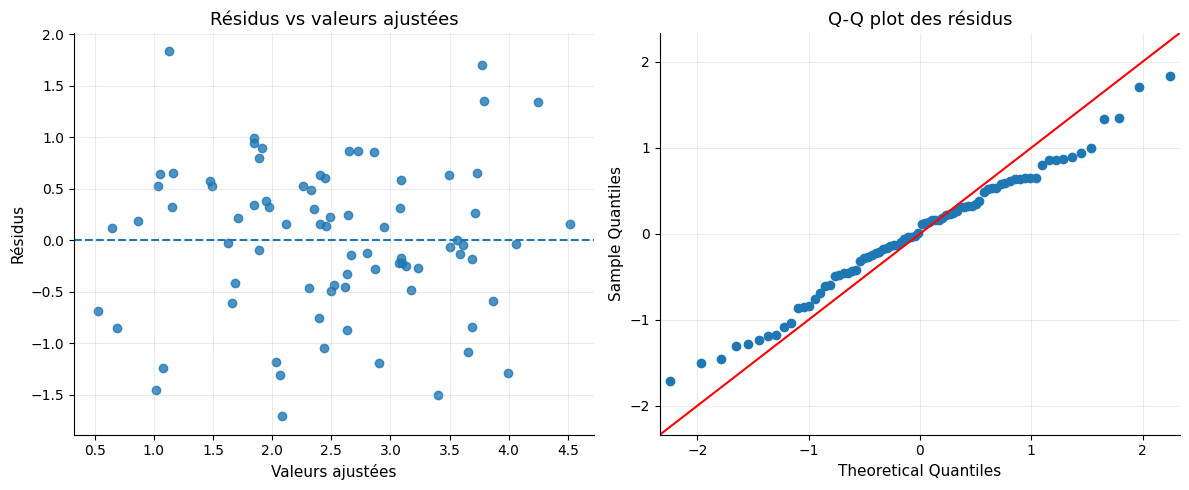

In [17]:
# Diagnostic graphique du modèle simple
fitted_vals = model_simple.fittedvalues
residuals = model_simple.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(fitted_vals, residuals, alpha=0.8)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Résidus vs valeurs ajustées")
axes[0].set_xlabel("Valeurs ajustées")
axes[0].set_ylabel("Résidus")

sm.qqplot(residuals, line="45", ax=axes[1])
axes[1].set_title("Q-Q plot des résidus")

plt.tight_layout()
plt.show()

## 7. Best subset selection pour la régression multiple

In [18]:
candidate_features = ["lvol", "lwht", "age", "lbh", "lpc"]
results = []

for k in range(1, len(candidate_features) + 1):
    for combo in combinations(candidate_features, k):
        predictors = list(combo)
        formula = TARGET + " ~ " + " + ".join(predictors)
        model = smf.ols(formula, data=prostate_log).fit()

        results.append({
            "n_features": k,
            "features": predictors,
            "R2": model.rsquared,
            "Adj_R2": model.rsquared_adj,
            "AIC": model.aic,
            "BIC": model.bic,
            "model": model,
        })

results_df = pd.DataFrame(results).sort_values(by="Adj_R2", ascending=False).reset_index(drop=True)
display(results_df[["n_features", "features", "R2", "Adj_R2", "AIC", "BIC"]].head(10))

,n_features,features,R2,Adj_R2,AIC,BIC
0,4,"[lvol, lwht, age, lpc]",0.661882,0.643849,178.661433,190.571566
1,5,"[lvol, lwht, age, lbh, lpc]",0.666371,0.643828,179.592168,193.884327
2,3,"[lvol, lwht, age]",0.656949,0.643408,177.820056,187.348163
3,4,"[lvol, lwht, age, lbh]",0.661032,0.642954,178.862122,190.772255
4,3,"[lvol, lwht, lpc]",0.654650,0.641018,178.354455,187.882562
5,2,"[lvol, lwht]",0.649879,0.640785,177.451930,184.598010
6,4,"[lvol, lwht, lbh, lpc]",0.656462,0.638140,179.933559,191.843693
7,3,"[lvol, lwht, lbh]",0.651471,0.637714,179.087332,188.615439
8,2,"[lvol, lbh]",0.629473,0.619849,181.983890,189.129970
9,3,"[lvol, age, lbh]",0.634269,0.619832,182.941596,192.469702


In [19]:
# Meilleur modèle selon l'Adjusted R²
best_row = results_df.iloc[0]
best_model = best_row["model"]

print("Meilleur modèle :")
print(f"- Nombre de variables : {best_row['n_features']}")
print(f"- Variables retenues : {best_row['features']}")
print(f"- R²                 : {best_row['R2']:.3f}")
print(f"- R² ajusté          : {best_row['Adj_R2']:.3f}")
print(f"- AIC                : {best_row['AIC']:.2f}")
print(f"- BIC                : {best_row['BIC']:.2f}")

print(best_model.summary())

Meilleur modèle :
- Nombre de variables : 4
- Variables retenues : ['lvol', 'lwht', 'age', 'lpc']
- R²                 : 0.662
- R² ajusté          : 0.644
- AIC                : 178.66
- BIC                : 190.57
                            OLS Regression Results                            
Dep. Variable:                   lpsa   R-squared:                       0.662
Model:                            OLS   Adj. R-squared:                  0.644
Method:                 Least Squares   F-statistic:                     36.70
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           5.65e-17
Time:                        18:07:36   Log-Likelihood:                -84.331
No. Observations:                  80   AIC:                             178.7
Df Residuals:                      75   BIC:                             190.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                    

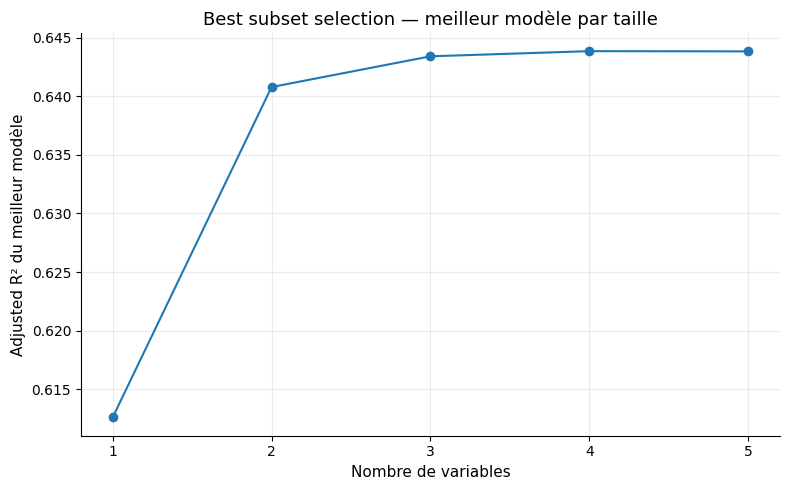

In [20]:
# Comparaison synthétique du meilleur modèle par taille
best_by_size = (
    results_df.sort_values(["n_features", "Adj_R2"], ascending=[True, False])
              .groupby("n_features", as_index=False)
              .first()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(best_by_size["n_features"], best_by_size["Adj_R2"], marker="o")
ax.set_xticks(best_by_size["n_features"])
ax.set_xlabel("Nombre de variables")
ax.set_ylabel("Adjusted R² du meilleur modèle")
ax.set_title("Best subset selection — meilleur modèle par taille")
plt.tight_layout()
plt.show()

In [21]:
print("Tests de pente nulle pour le meilleur modèle :")
coef_table = pd.DataFrame({
    "coef": best_model.params,
    "t": best_model.tvalues,
    "p_value": best_model.pvalues,
    "CI_low": best_model.conf_int()[0],
    "CI_high": best_model.conf_int()[1],
})
display(coef_table.round(4))

Tests de pente nulle pour le meilleur modèle :


,coef,t,p_value,CI_low,CI_high
Intercept,0.2523,0.2974,0.7670,-1.4379,1.9425
lvol,0.6745,7.1022,0.0000,0.4853,0.8637
lwht,0.6320,2.9902,0.0038,0.2110,1.0531
age,-0.0140,-1.2665,0.2092,-0.0361,0.0080
lpc,0.0814,1.0460,0.2989,-0.0736,0.2364


## 8. Prédiction pour un nouveau patient

In [22]:
new_patient_raw = {
    "vol": 7.2,
    "wht": 22,
    "bh": 1.5,
    "pc": 0.26,
    "age": 67,
}

new_patient = {
    "lvol": np.log(new_patient_raw["vol"]),
    "lwht": np.log(new_patient_raw["wht"]),
    "lbh": np.log(new_patient_raw["bh"]),
    "lpc": np.log(new_patient_raw["pc"]),
    "age": new_patient_raw["age"],
}

new_patient_df = pd.DataFrame([new_patient])
pred_lpsa = best_model.predict(new_patient_df).iloc[0]
pred_psa = np.exp(pred_lpsa)

print(f"Prédiction lpsa : {pred_lpsa:.3f}")
print(f"Prédiction psa  : {pred_psa:.3f}")

Prédiction lpsa : 2.489
Prédiction psa  : 12.044
